In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
import seaborn as sns
from pathlib import Path

# ── Load and concatenate all CSV files in the directory ──
CSV_DIR = "/Users/giuliaam/Desktop/Newlife/ML_Project/CompoundsData/OutputCP"

csv_files = sorted(Path(CSV_DIR).rglob("*.csv"))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {f.name}")

# Load and concatenate — adds a column to track which replicate each cell came from
dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp['Replicate'] = f.stem   # filename without extension = replicate ID
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

print(f"\nTotal cells loaded: {len(df)}")
print("\nCells per condition:")
print(df.groupby('Condition').size().sort_values(ascending=False))
print("\nCells per replicate:")
print(df.groupby('Replicate').size())

Found 4 CSV files:
  - 240416nuclei_measurements.csv
  - 241018nuclei_measurements.csv
  - 241110nuclei_measurements.csv
  - 250323nuclei_measurements.csv

Total cells loaded: 231

Cells per condition:
Condition
DMSO      59
Blebbi    50
CytoD     36
LatA      30
CK666     26
Noco      24
NCS        4
ML1        1
Y27632     1
dtype: int64

Cells per replicate:
Replicate
240416nuclei_measurements    95
241018nuclei_measurements    25
241110nuclei_measurements    57
250323nuclei_measurements    54
dtype: int64


Found 4 CSV files:
  - 240416nuclei_measurements.csv
  - 241018nuclei_measurements.csv
  - 241110nuclei_measurements.csv
  - 250323nuclei_measurements.csv

Total cells loaded: 231

Cells per condition:
Condition
DMSO      59
Blebbi    50
CytoD     36
LatA      30
CK666     26
Noco      24
NCS        4
ML1        1
Y27632     1
dtype: int64

Cells per replicate:
Replicate
240416nuclei_measurements    95
241018nuclei_measurements    25
241110nuclei_measurements    57
250323nuclei_measurements    54
dtype: int64

Keeping conditions (>= 8 cells): ['Blebbi', 'CK666', 'CytoD', 'DMSO', 'LatA', 'Noco']
Dropping conditions (too few cells): ['ML1', 'NCS', 'Y27632']

Cells after filtering: 225

Classes: ['Blebbi' 'CK666' 'CytoD' 'DMSO' 'LatA' 'Noco']

PCA explained variance: PC1=42.1%, PC2=23.1%


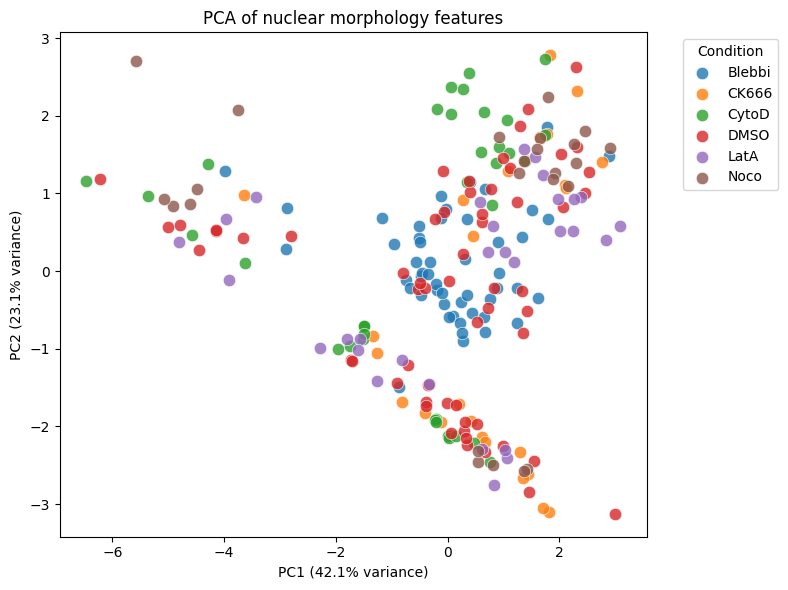

PCA plot saved ✓

PCA loadings (which features drive separation):
                             PC1    PC2
Equivalent_diameter_um     0.473 -0.244
Perimeter_um               0.464 -0.249
Area_um2                   0.448 -0.284
Solidity                   0.348 -0.100
DAPI_integrated_intensity  0.343  0.460
DAPI_mean_intensity        0.266  0.557
Actin_mean_intensity       0.196  0.478
Eccentricity              -0.106 -0.010
Orientation_rad            0.041 -0.193


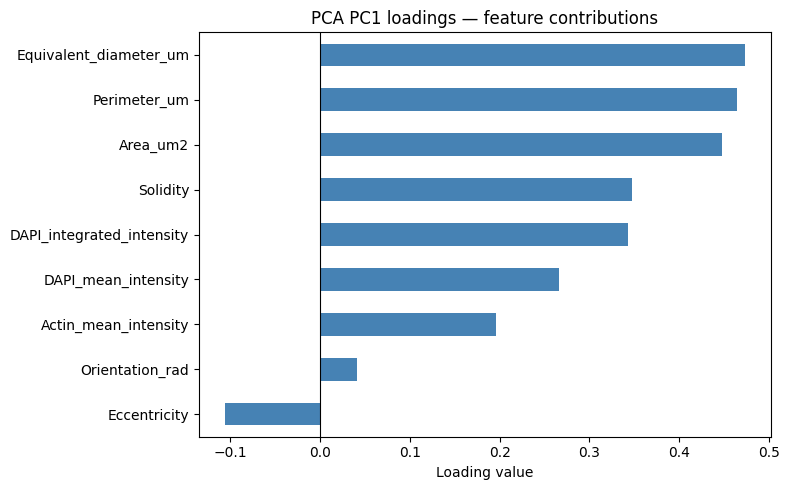


Running 5-fold stratified cross-validation...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Blebbi       0.78      0.86      0.82        50
       CK666       0.50      0.31      0.38        26
       CytoD       0.61      0.64      0.62        36
        DMSO       0.36      0.37      0.37        59
        LatA       0.76      0.83      0.79        30
        Noco       0.41      0.38      0.39        24

    accuracy                           0.58       225
   macro avg       0.57      0.56      0.56       225
weighted avg       0.57      0.58      0.57       225



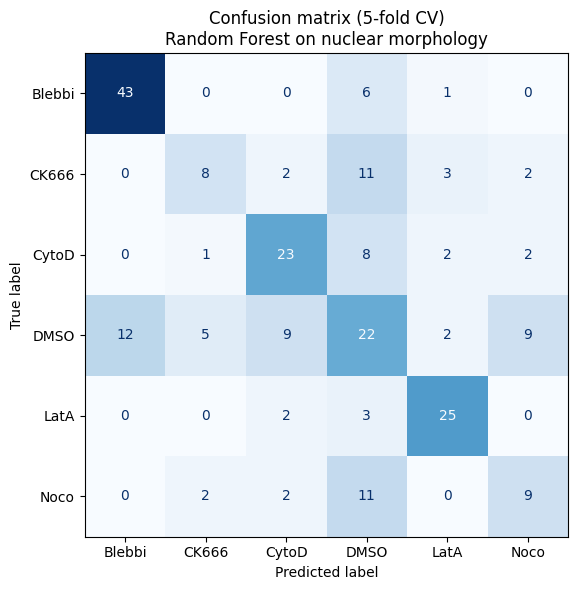

Confusion matrix saved ✓


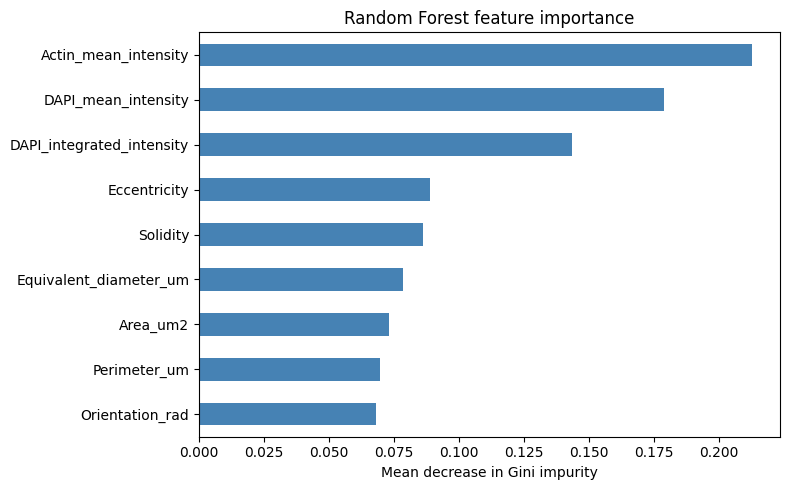

Feature importance plot saved ✓

=== TOP 3 MOST IMPORTANT FEATURES ===
Actin_mean_intensity         0.212992
DAPI_mean_intensity          0.179090
DAPI_integrated_intensity    0.143660
dtype: float64


In [15]:
"""
03_classifier.py
================
Classical ML classifier on nuclear morphology measurements.

Steps:
    1. Load and merge all CSV files
    2. Explore and visualize the data
    3. PCA visualization — do conditions separate?
    4. Random Forest classifier with cross-validation
    5. Feature importance — which features matter most?
    6. Confusion matrix — where does the classifier struggle?

Design:
    - Uses StratifiedKFold cross-validation (essential for small datasets)
      This means we train/evaluate K times, each time using a different
      subset as validation. More reliable than a single train/val split.
    - Filters out conditions with too few cells (< MIN_CELLS_PER_CONDITION)
    - Scales features with StandardScaler before PCA and classification
"""

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# ============================================================
# PARAMETERS
# ============================================================

# Folder containing all your nuclei_measurements CSV files
CSV_DIR = "/Users/giuliaam/Desktop/Newlife/ML_Project"

# Minimum cells per condition to be included in classifier
# Conditions below this threshold are dropped
MIN_CELLS_PER_CONDITION = 8

# Features to use for classification
# We exclude metadata columns and centroid (position is not a biological feature)
FEATURE_COLS = [
    "Area_um2",
    "Equivalent_diameter_um",
    "Perimeter_um",
    "Eccentricity",
    "Solidity",
    "Orientation_rad",
    "DAPI_mean_intensity",
    "DAPI_integrated_intensity",
    "Actin_mean_intensity",
]

# Cross-validation folds
N_FOLDS = 5

# Random Forest parameters
N_TREES = 200
RANDOM_STATE = 42

# ============================================================
# STEP 1 — LOAD AND MERGE ALL CSV FILES
# ============================================================

# Find all CSV files recursively
csv_files = sorted(glob.glob(f"{CSV_DIR}/**/*measurements*.csv", recursive=True))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {Path(f).name}")

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {CSV_DIR}")

# Load and concatenate — add replicate column from filename
dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp['Replicate'] = Path(f).stem
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal cells loaded: {len(df)}")
print("\nCells per condition:")
print(df.groupby('Condition').size().sort_values(ascending=False))
print("\nCells per replicate:")
print(df.groupby('Replicate').size())

# ============================================================
# STEP 2 — FILTER CONDITIONS
# ============================================================

# Count cells per condition
counts = df.groupby('Condition').size()
valid_conditions = counts[counts >= MIN_CELLS_PER_CONDITION].index.tolist()
dropped = counts[counts < MIN_CELLS_PER_CONDITION].index.tolist()

print(f"\nKeeping conditions (>= {MIN_CELLS_PER_CONDITION} cells): {valid_conditions}")
print(f"Dropping conditions (too few cells): {dropped}")

df_filtered = df[df['Condition'].isin(valid_conditions)].copy()
print(f"\nCells after filtering: {len(df_filtered)}")

# ============================================================
# STEP 3 — PREPARE FEATURE MATRIX
# ============================================================

X = df_filtered[FEATURE_COLS].values
y = df_filtered['Condition'].values

# Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"\nClasses: {class_names}")

# Scale features to zero mean and unit variance
# This is important for PCA and helps classifiers that are sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 4 — PCA VISUALIZATION
# ============================================================
# PCA (Principal Component Analysis) finds the directions of maximum variance
# in your feature space. Projecting onto the first 2 PCs gives a 2D view
# of how well your conditions separate based on morphological features.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"\nPCA explained variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%")

# Color palette — one color per condition
palette = sns.color_palette("tab10", len(class_names))
color_map = {cond: palette[i] for i, cond in enumerate(class_names)}

fig, ax = plt.subplots(figsize=(8, 6))
for cond in class_names:
    mask = df_filtered['Condition'] == cond
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=cond,
        color=color_map[cond],
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
ax.set_title("PCA of nuclear morphology features")
ax.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{CSV_DIR}/pca_conditions.png", dpi=150, bbox_inches='tight')
plt.show()
print("PCA plot saved ✓")

# ============================================================
# STEP 5 — PCA LOADINGS
# ============================================================
# Loadings tell you which original features contribute most to each PC.
# A high loading on PC1 means that feature drives the main separation.

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=['PC1', 'PC2']
).sort_values('PC1', key=abs, ascending=False)

print("\nPCA loadings (which features drive separation):")
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
loadings['PC1'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("PCA PC1 loadings — feature contributions")
ax.set_xlabel("Loading value")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{CSV_DIR}/pca_loadings.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 6 — RANDOM FOREST WITH CROSS-VALIDATION
# ============================================================
# StratifiedKFold preserves class proportions in each fold.
# cross_val_predict runs the full CV loop and collects out-of-fold predictions
# — every sample is predicted exactly once, on data the model never saw.
# This gives an unbiased estimate of generalization performance.

print(f"\nRunning {N_FOLDS}-fold stratified cross-validation...")

rf = RandomForestClassifier(
    n_estimators=N_TREES,
    class_weight='balanced',   # compensates for class imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1                  # use all CPU cores
)

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Get out-of-fold predictions for every sample
y_pred = cross_val_predict(rf, X_scaled, y_encoded, cv=cv)
y_pred_labels = le.inverse_transform(y_pred)
y_true_labels = le.inverse_transform(y_encoded)

# Classification report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true_labels, y_pred_labels))

# ============================================================
# STEP 7 — CONFUSION MATRIX
# ============================================================
# Rows = true condition, Columns = predicted condition.
# A perfect classifier has values only on the diagonal.
# Off-diagonal values show which conditions get confused with each other
# — biologically interesting! (e.g. CytoD and LatA both depolymerize actin
#   so the classifier might confuse them)

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"Confusion matrix ({N_FOLDS}-fold CV)\nRandom Forest on nuclear morphology")
plt.tight_layout()
plt.savefig(f"{CSV_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✓")

# ============================================================
# STEP 8 — FEATURE IMPORTANCE
# ============================================================
# Random Forest computes feature importance as the average decrease
# in impurity (Gini) when splitting on each feature across all trees.
# High importance = that feature is most useful for distinguishing conditions.

# Fit once on full data to get stable importances
rf.fit(X_scaled, y_encoded)
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Mean decrease in Gini impurity")
plt.tight_layout()
plt.savefig(f"{CSV_DIR}/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved ✓")

print("\n=== TOP 3 MOST IMPORTANT FEATURES ===")
print(importances.sort_values(ascending=False).head(3))